# Indian Roads Dataset - Exploratory Data Analysis (EDA)
## Uncovering Hidden Patterns in Road Accidents Across India

This notebook performs a comprehensive exploratory analysis of road accident data across Indian cities, identifying patterns, correlations, and insights that can help reduce accidents.

## 1. Import Libraries & Load Data

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
px.defaults.template = "plotly_white"
px.defaults.color_continuous_scale = "viridis"

# Load the dataset
df = pd.read_csv("C:/Users/kunal/Desktop/Car Accident project/archive/indian_roads_dataset.csv")
print("✓ Data loaded successfully!")
print(f"Dataset shape: {df.shape}")

✓ Data loaded successfully!
Dataset shape: (20000, 24)


## 2. Data Overview & Structure

In [40]:
# Display basic information
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
print(f"\nShape: {df.shape}")
print(f"\nColumn Names & Types:")
print(df.dtypes)
print(f"\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Records: {df.duplicated().sum()}")

DATASET INFORMATION

Shape: (20000, 24)

Column Names & Types:
accident_id            int64
city                  object
state                 object
latitude             float64
longitude            float64
date                  object
time                  object
hour                   int64
day_of_week           object
is_weekend             int64
road_type             object
lanes                  int64
traffic_signal         int64
weather               object
visibility            object
temperature            int64
traffic_density       object
cause                 object
accident_severity     object
vehicles_involved      int64
casualties             int64
is_peak_hour           int64
festival              object
risk_score           float64
dtype: object

Missing Values:
accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                 

In [41]:
# First few rows
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [42]:
# Statistical summary
print("\n=" * 80)
print("STATISTICAL SUMMARY")
print("=" * 80)
df.describe().T


=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
=
STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
accident_id,20000.0,9999.500000,5773.647028,0.000000,4999.750000,9999.500000,14999.250000,19999.000000
latitude,20000.0,20.389207,6.165791,12.800172,13.198653,18.812008,28.402467,30.799960
longitude,20000.0,78.173330,4.485967,72.700017,73.997979,77.297000,80.111089,88.499861
hour,20000.0,11.487200,6.945563,0.000000,5.000000,12.000000,18.000000,23.000000
is_weekend,20000.0,0.286150,0.451972,0.000000,0.000000,0.000000,1.000000,1.000000
lanes,20000.0,3.493950,1.705406,1.000000,2.000000,4.000000,5.000000,6.000000
traffic_signal,20000.0,0.499850,0.500012,0.000000,0.000000,0.000000,1.000000,1.000000
temperature,20000.0,27.579600,7.454746,15.000000,21.000000,28.000000,34.000000,40.000000
vehicles_involved,20000.0,2.992000,1.415534,1.000000,2.000000,3.000000,4.000000,5.000000
casualties,20000.0,1.726450,1.489104,0.000000,1.000000,1.000000,3.000000,5.000000


## 3. Data Cleaning & Preprocessing

In [43]:
# Handle missing values
df['festival'].fillna('No Festival', inplace=True)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()

print("✓ Data cleaning completed!")
print(f"\nProcessed columns: {df.columns.tolist()}")

✓ Data cleaning completed!

Processed columns: ['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score', 'year', 'month', 'month_name']


## 4. Univariate Analysis - Numerical Features

In [44]:
# Distribution of numerical variables
numerical_cols = ['hour', 'lanes', 'temperature', 'vehicles_involved', 'casualties', 'risk_score']

fig = make_subplots(rows=2, cols=3, subplot_titles=[f'Distribution of {col}' for col in numerical_cols])
for idx, col in enumerate(numerical_cols):
    row = idx // 3 + 1
    col_idx = idx % 3 + 1
    fig.add_trace(
        go.Histogram(x=df[col], nbinsx=30, marker_color='steelblue', opacity=0.85, name=col),
        row=row,
        col=col_idx
    )
    fig.update_xaxes(title_text=col, row=row, col=col_idx)
    fig.update_yaxes(title_text='Frequency', row=row, col=col_idx)

fig.update_layout(
    title_text='Numerical Feature Distributions',
    height=900,
    width=1200,
    bargap=0.15,
    showlegend=False
)
fig.show()

print("\n" + "="*80)
print("KEY INSIGHTS - NUMERICAL FEATURES")
print("="*80)
for col in numerical_cols:
    print(f"\n{col.upper()}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Min: {df[col].min():.2f}, Max: {df[col].max():.2f}")


KEY INSIGHTS - NUMERICAL FEATURES

HOUR:
  Mean: 11.49
  Median: 12.00
  Std Dev: 6.95
  Min: 0.00, Max: 23.00

LANES:
  Mean: 3.49
  Median: 4.00
  Std Dev: 1.71
  Min: 1.00, Max: 6.00

TEMPERATURE:
  Mean: 27.58
  Median: 28.00
  Std Dev: 7.45
  Min: 15.00, Max: 40.00

VEHICLES_INVOLVED:
  Mean: 2.99
  Median: 3.00
  Std Dev: 1.42
  Min: 1.00, Max: 5.00

CASUALTIES:
  Mean: 1.73
  Median: 1.00
  Std Dev: 1.49
  Min: 0.00, Max: 5.00

RISK_SCORE:
  Mean: 0.44
  Median: 0.45
  Std Dev: 0.22
  Min: 0.10, Max: 1.00


## 5. Univariate Analysis - Categorical Features

In [45]:
# Categorical variables distribution
categorical_cols = ['city', 'road_type', 'weather', 'visibility', 'traffic_density', 
                     'cause', 'accident_severity', 'day_of_week']

fig = make_subplots(rows=2, cols=4, subplot_titles=categorical_cols, horizontal_spacing=0.06, vertical_spacing=0.10)
for idx, col in enumerate(categorical_cols):
    row = idx // 4 + 1
    col_idx = idx % 4 + 1
    counts = df[col].value_counts().head(6)
    fig.add_trace(
        go.Bar(x=counts.values, y=counts.index, orientation='h', marker_color='indianred', name=col,
               hovertemplate='%{y}: %{x}<extra></extra>'),
        row=row,
        col=col_idx
    )
    fig.update_xaxes(title_text='Count', row=row, col=col_idx)
    fig.update_yaxes(title_text='' if idx != 0 else col, row=row, col=col_idx)

fig.update_layout(
    title_text='Top Categories for Categorical Features',
    height=900,
    width=1400,
    showlegend=False
)
fig.show()

In [46]:
# Detailed categorical analysis
print("=" * 80)
print("CATEGORICAL FEATURES - UNIQUE VALUES")
print("=" * 80)

for col in categorical_cols:
    print(f"\n{col.upper()} - {df[col].nunique()} unique values:")
    print(df[col].value_counts())

CATEGORICAL FEATURES - UNIQUE VALUES

CITY - 8 unique values:
city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

ROAD_TYPE - 3 unique values:
road_type
urban      6745
rural      6639
highway    6616
Name: count, dtype: int64

WEATHER - 3 unique values:
weather
clear    6690
rain     6677
fog      6633
Name: count, dtype: int64

VISIBILITY - 3 unique values:
visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

TRAFFIC_DENSITY - 3 unique values:
traffic_density
low       7067
high      7034
medium    5899
Name: count, dtype: int64

CAUSE - 5 unique values:
cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

ACCIDENT_SEVERITY - 3 unique values:
accident_severity
minor    11025
major     5988
fatal     2987
Name: count, dtype: int64

DAY_O

## 6. Hidden Pattern #1: Peak Hours & Time-Based Patterns

In [47]:
# Accidents by hour of day
hourly_accidents = df.groupby('hour').size()
peak_hour_dist = df['is_peak_hour'].map({0: 'Non-Peak', 1: 'Peak'}).value_counts()
weekend_dist = df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'}).value_counts()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_accidents = df['day_of_week'].value_counts().reindex(day_order)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Accidents by Hour of Day',
        'Peak vs Non-Peak Hour Accidents',
        'Accidents: Weekday vs Weekend',
        'Accidents by Day of Week'
    ],
    specs=[[{"type":"xy"}, {"type":"domain"}], [{"type":"xy"}, {"type":"xy"}]],
    horizontal_spacing=0.12,
    vertical_spacing=0.12
)

fig.add_trace(
    go.Scatter(x=hourly_accidents.index, y=hourly_accidents.values,
               mode='lines+markers', line=dict(color='#D62728', width=3), marker=dict(size=8),
               hovertemplate='Hour %{x}: %{y} accidents<extra></extra>'),
    row=1, col=1
)
fig.add_trace(
    go.Pie(labels=peak_hour_dist.index, values=peak_hour_dist.values,
           hole=0.35, marker_colors=['lightskyblue', 'tomato'], textinfo='percent+label'),
    row=1, col=2
)
fig.add_trace(
    go.Bar(x=weekend_dist.index, y=weekend_dist.values, marker_color=['seagreen', 'darkorange'],
           hovertemplate='%{x}: %{y} accidents<extra></extra>'),
    row=2, col=1
)
fig.add_trace(
    go.Bar(x=[d[:3] for d in day_order], y=daily_accidents.values,
           marker_color='teal', hovertemplate='%{x}: %{y}<extra></extra>'),
    row=2, col=2
)

fig.update_xaxes(title_text='Hour of Day', row=1, col=1)
fig.update_yaxes(title_text='Accidents', row=1, col=1)
fig.update_xaxes(title_text='Day', row=2, col=2)
fig.update_yaxes(title_text='Accidents', row=2, col=2)

fig.update_layout(
    title_text='Time-Based Accident Patterns',
    height=850,
    width=1200,
    showlegend=False
)
fig.show()

print("\n" + "="*80)
print("TIME-BASED PATTERNS INSIGHTS")
print("="*80)
print(f"\nPeak Hour Accidents: {peak_hour_dist.get('Peak', 0)} ({peak_hour_dist.get('Peak', 0)/len(df)*100:.1f}%)")
print(f"Most dangerous hour: {hourly_accidents.idxmax()} (hour) with {hourly_accidents.max()} accidents")
print(f"Safest hour: {hourly_accidents.idxmin()} (hour) with {hourly_accidents.min()} accidents")
print(f"\nWeekend Accidents: {weekend_dist.get('Weekend', 0)} ({weekend_dist.get('Weekend', 0)/len(df)*100:.1f}%)")
print(f"Most dangerous day: {daily_accidents.idxmax()} with {daily_accidents.max()} accidents")



TIME-BASED PATTERNS INSIGHTS

Peak Hour Accidents: 4948 (24.7%)
Most dangerous hour: 2 (hour) with 888 accidents
Safest hour: 7 (hour) with 786 accidents

Weekend Accidents: 5723 (28.6%)
Most dangerous day: Monday with 2966 accidents


## 7. Hidden Pattern #2: Weather & Environmental Factors

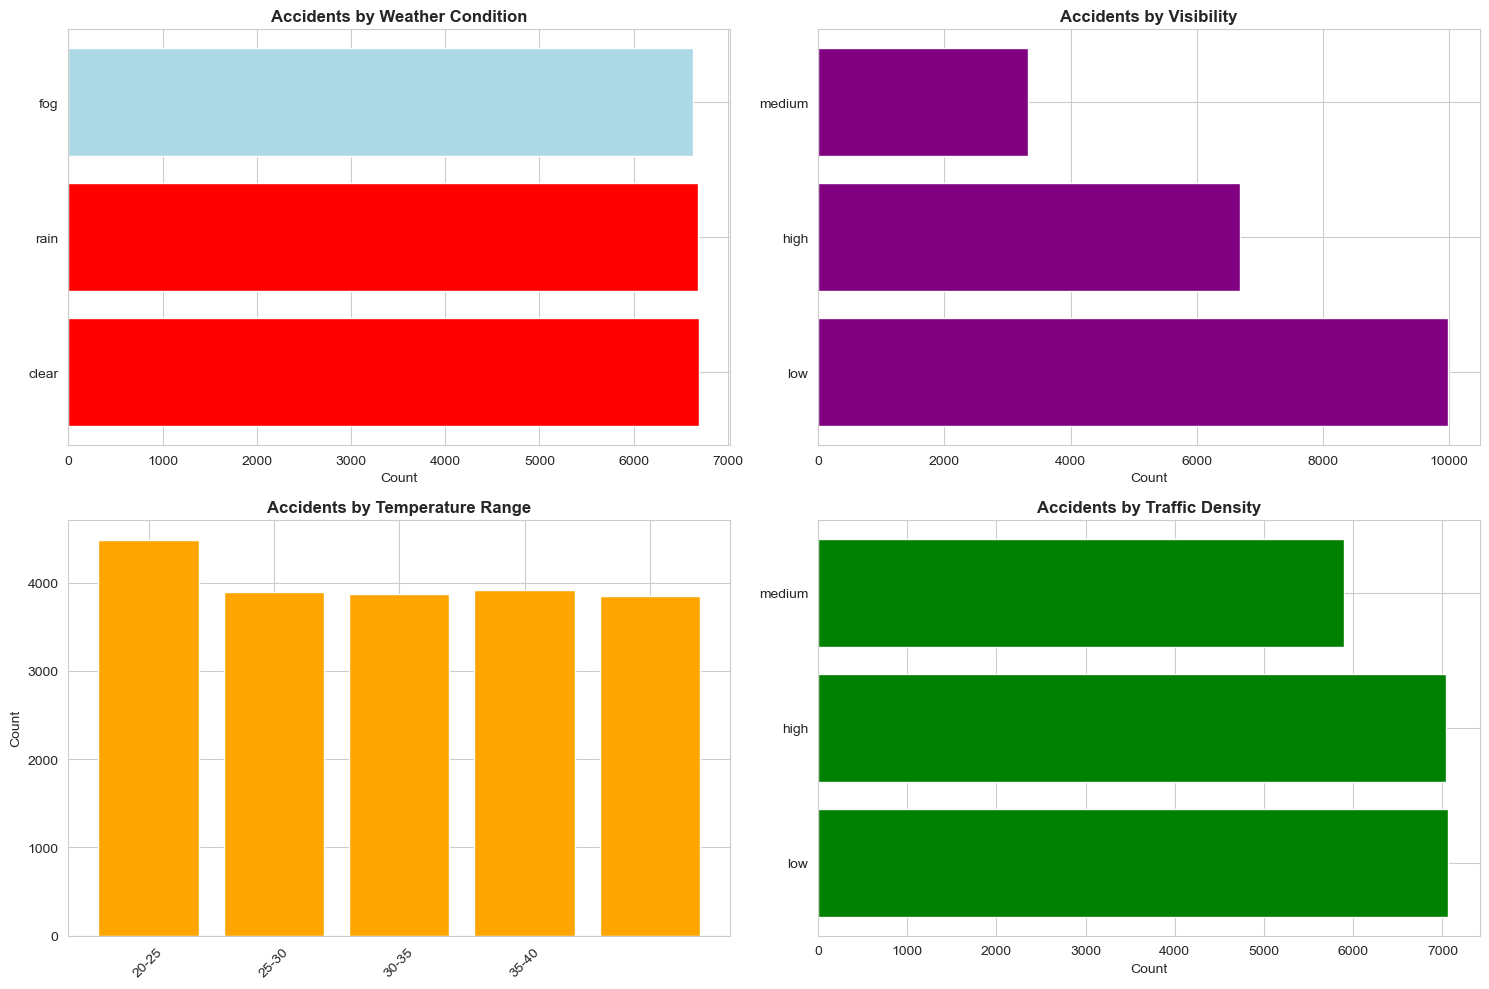


WEATHER & ENVIRONMENTAL PATTERNS

Most dangerous weather: clear (6690 accidents)

Visibility impact:
visibility
low       9987
high      6690
medium    3323
Name: count, dtype: int64

Temperature impact:
temperature
(14.975, 20.0]    4487
(20.0, 25.0]      3889
(25.0, 30.0]      3866
(30.0, 35.0]      3914
(35.0, 40.0]      3844
dtype: int64


In [48]:
# Weather impact analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weather distribution
weather_counts = df['weather'].value_counts()
colors_weather = ['red' if x > weather_counts.mean() else 'lightblue' for x in weather_counts.values]
axes[0, 0].barh(weather_counts.index, weather_counts.values, color=colors_weather)
axes[0, 0].set_title('Accidents by Weather Condition', fontweight='bold')
axes[0, 0].set_xlabel('Count')

# Visibility impact
visibility_counts = df['visibility'].value_counts()
axes[0, 1].barh(visibility_counts.index, visibility_counts.values, color='purple')
axes[0, 1].set_title('Accidents by Visibility', fontweight='bold')
axes[0, 1].set_xlabel('Count')

# Temperature vs accidents
temp_range = pd.cut(df['temperature'], bins=5)
temp_accidents = df.groupby(temp_range).size()
axes[1, 0].bar(range(len(temp_accidents)), temp_accidents.values, color='orange')
axes[1, 0].set_xticklabels([f'{int(x.left)}-{int(x.right)}' for x in temp_accidents.index], rotation=45)
axes[1, 0].set_title('Accidents by Temperature Range', fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Traffic density impact
density_counts = df['traffic_density'].value_counts()
axes[1, 1].barh(density_counts.index, density_counts.values, color='green')
axes[1, 1].set_title('Accidents by Traffic Density', fontweight='bold')
axes[1, 1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("WEATHER & ENVIRONMENTAL PATTERNS")
print("="*80)
print(f"\nMost dangerous weather: {weather_counts.idxmax()} ({weather_counts.max()} accidents)")
print(f"\nVisibility impact:")
print(visibility_counts)
print(f"\nTemperature impact:")
print(temp_accidents)

## 8. Hidden Pattern #3: Road Type & Infrastructure

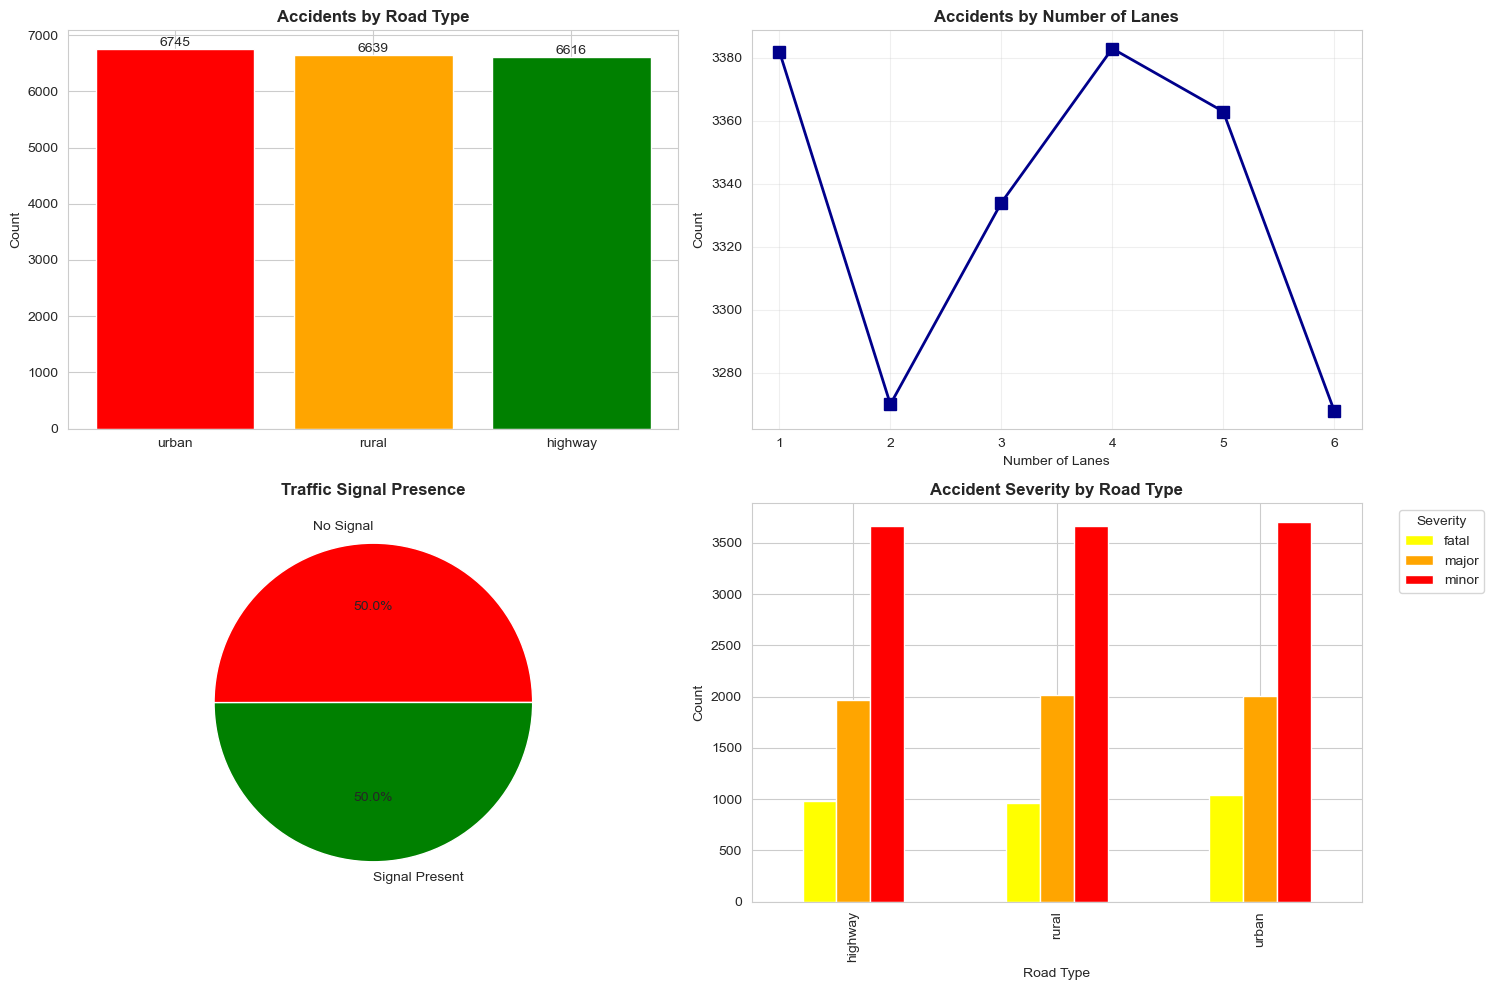


ROAD INFRASTRUCTURE PATTERNS

Road Type Distribution:
road_type
urban      6745
rural      6639
highway    6616
Name: count, dtype: int64

Most accident-prone road type: urban

Traffic Signal Impact:
  Without signal: 10003 accidents
  With signal: 9997 accidents

Number of Lanes - Most accidents: 4 lanes


In [56]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Road type analysis
road_counts = df['road_type'].value_counts()
axes[0, 0].bar(road_counts.index, road_counts.values, color=['red', 'orange', 'green'])
axes[0, 0].set_title('Accidents by Road Type', fontweight='bold')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(road_counts.values):
    axes[0, 0].text(i, v, str(v), ha='center', va='bottom')

# Lanes analysis
lanes_accidents = df.groupby('lanes').size().sort_index()
axes[0, 1].plot(lanes_accidents.index, lanes_accidents.values, marker='s', linewidth=2, markersize=8, color='darkblue')
axes[0, 1].set_title('Accidents by Number of Lanes', fontweight='bold')
axes[0, 1].set_xlabel('Number of Lanes')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

# Traffic signal impact
signal_counts = df['traffic_signal'].value_counts()
axes[1, 0].pie(signal_counts.values, labels=['No Signal', 'Signal Present'], autopct='%1.1f%%', colors=['red', 'green'])
axes[1, 0].set_title('Traffic Signal Presence', fontweight='bold')

# Road type vs severity
road_severity = pd.crosstab(df['road_type'], df['accident_severity'])
road_severity.plot(kind='bar', ax=axes[1, 1], color=['yellow', 'orange', 'red'])
axes[1, 1].set_title('Accident Severity by Road Type', fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('Road Type')
axes[1, 1].legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ROAD INFRASTRUCTURE PATTERNS")
print("="*80)
print(f"\nRoad Type Distribution:")
print(road_counts)
print(f"\nMost accident-prone road type: {road_counts.idxmax()}")
print(f"\nTraffic Signal Impact:")
print(f"  Without signal: {signal_counts[0]} accidents")
print(f"  With signal: {signal_counts[1]} accidents")
print(f"\nNumber of Lanes - Most accidents: {lanes_accidents.idxmax()} lanes")

## 9. Hidden Pattern #4: Accident Causes & Severity

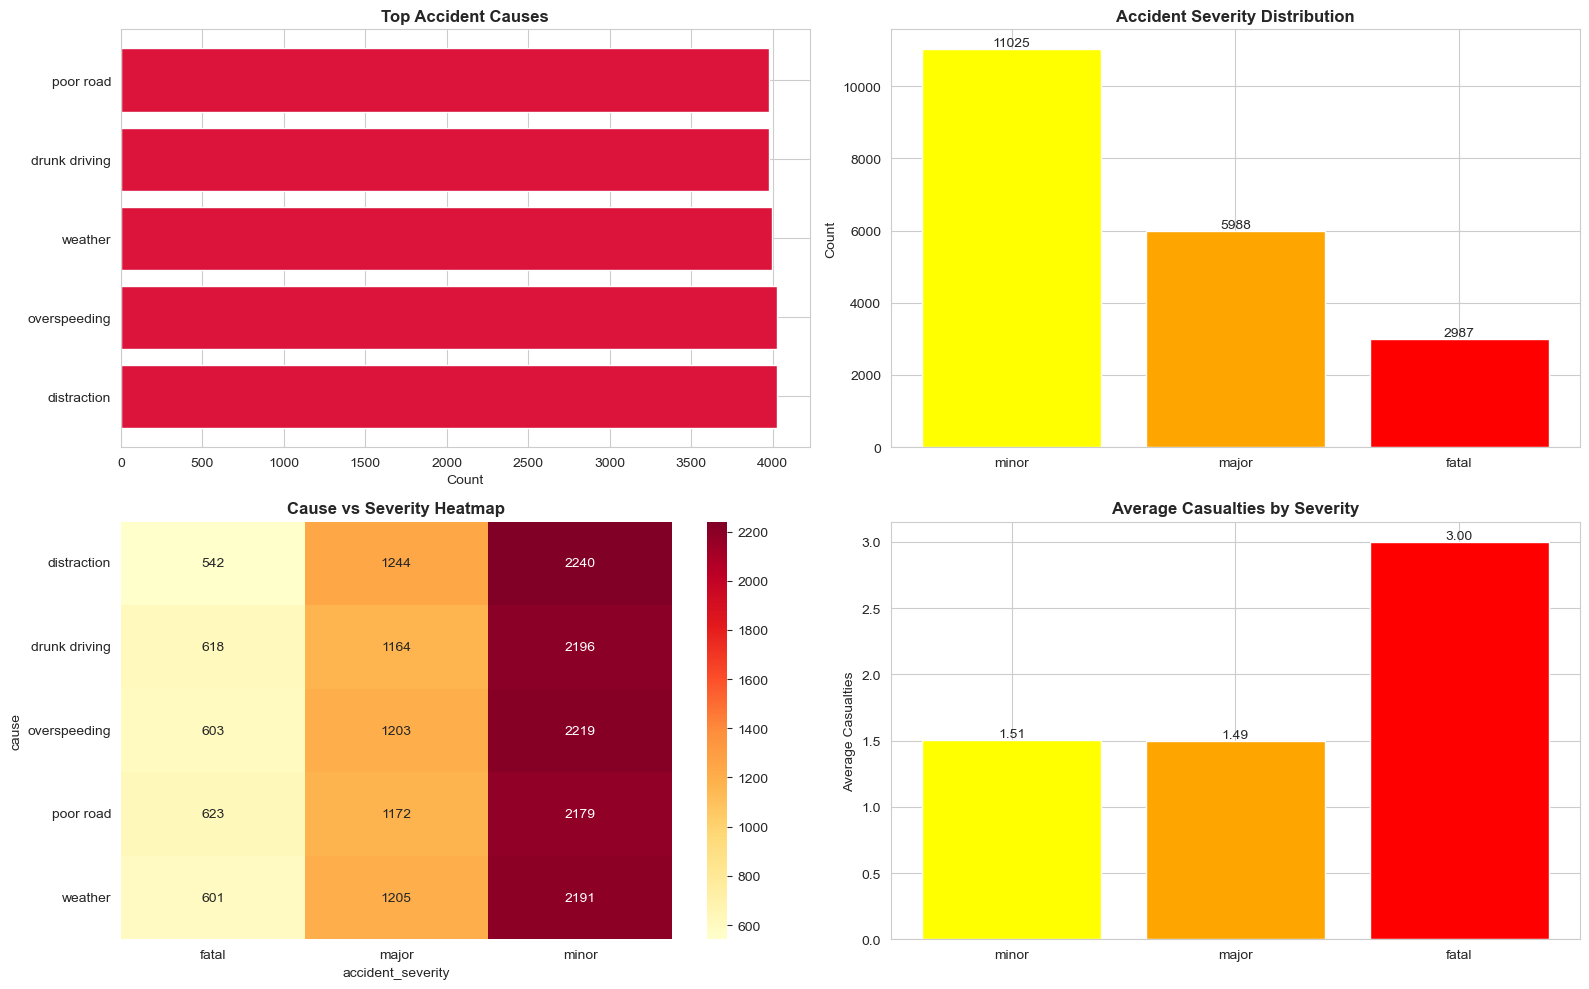


ACCIDENT CAUSES & SEVERITY ANALYSIS

Top 5 Accident Causes:
cause
distraction      4026
overspeeding     4025
weather          3997
drunk driving    3978
poor road        3974
Name: count, dtype: int64

Severity Distribution (percentage):
accident_severity
minor    55.12
major    29.94
fatal    14.94
Name: count, dtype: float64

Average Casualties by Severity:
accident_severity
minor    1.506757
major    1.494823
fatal    3.001674
Name: casualties, dtype: float64


In [50]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Cause of accidents
cause_counts = df['cause'].value_counts()
axes[0, 0].barh(cause_counts.index, cause_counts.values, color='crimson')
axes[0, 0].set_title('Top Accident Causes', fontweight='bold')
axes[0, 0].set_xlabel('Count')

# Severity distribution
severity_counts = df['accident_severity'].value_counts()
severity_order = ['minor', 'major', 'fatal']
severity_counts = severity_counts.reindex(severity_order)
colors_severity = ['yellow', 'orange', 'red']
axes[0, 1].bar(severity_counts.index, severity_counts.values, color=colors_severity)
axes[0, 1].set_title('Accident Severity Distribution', fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(severity_counts.values):
    axes[0, 1].text(i, v, str(v), ha='center', va='bottom')

# Cause vs Severity heatmap
cause_severity = pd.crosstab(df['cause'], df['accident_severity'])
sns.heatmap(cause_severity, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0], cbar=True)
axes[1, 0].set_title('Cause vs Severity Heatmap', fontweight='bold')

# Casualties vs Severity
severity_casualties = df.groupby('accident_severity')['casualties'].mean().reindex(severity_order)
axes[1, 1].bar(severity_casualties.index, severity_casualties.values, color=colors_severity)
axes[1, 1].set_title('Average Casualties by Severity', fontweight='bold')
axes[1, 1].set_ylabel('Average Casualties')
for i, v in enumerate(severity_casualties.values):
    axes[1, 1].text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("ACCIDENT CAUSES & SEVERITY ANALYSIS")
print("="*80)
print(f"\nTop 5 Accident Causes:")
print(cause_counts.head())
print(f"\nSeverity Distribution (percentage):")
print((severity_counts / len(df) * 100).round(2))
print(f"\nAverage Casualties by Severity:")
print(severity_casualties)

## 10. Hidden Pattern #5: Geographic Hotspots

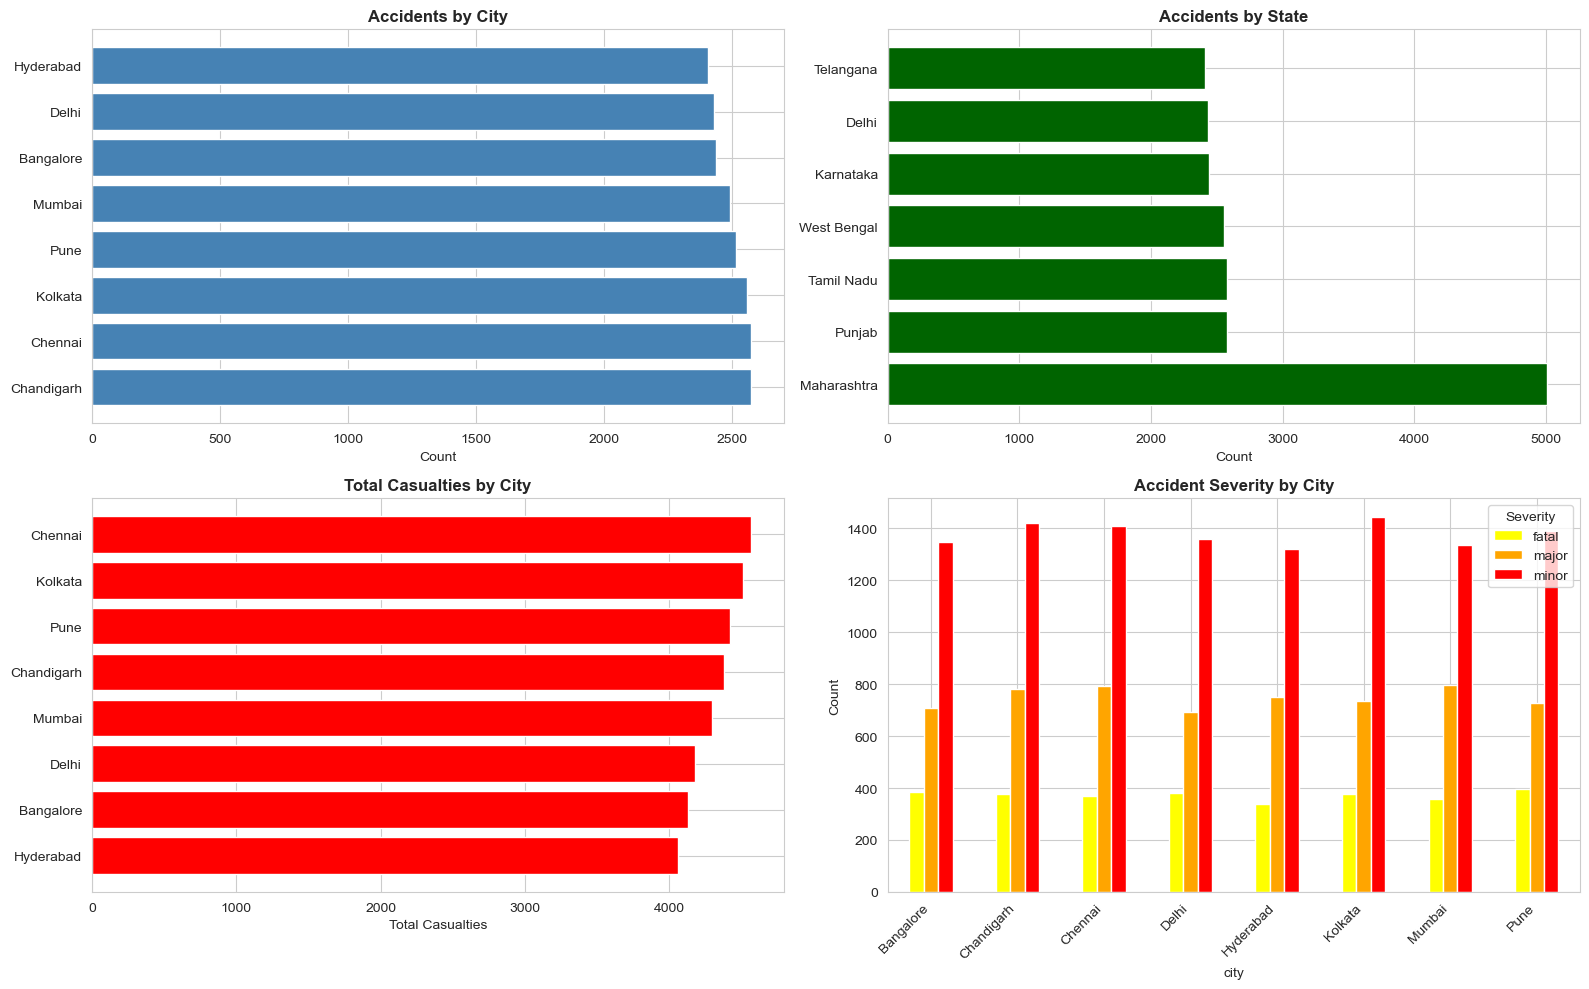


GEOGRAPHIC HOTSPOTS

City-wise Accident Count:
city
Chandigarh    2577
Chennai       2575
Kolkata       2559
Pune          2517
Mumbai        2492
Bangalore     2438
Delhi         2433
Hyderabad     2409
Name: count, dtype: int64

Most dangerous city: Chandigarh

Total Casualties by City:
city
Hyderabad     4058
Bangalore     4128
Delhi         4175
Mumbai        4297
Chandigarh    4377
Pune          4419
Kolkata       4508
Chennai       4567
Name: casualties, dtype: int64

City with highest casualties: Chennai


In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# City-wise accidents
city_counts = df['city'].value_counts()
axes[0, 0].barh(city_counts.index, city_counts.values, color='steelblue')
axes[0, 0].set_title('Accidents by City', fontweight='bold')
axes[0, 0].set_xlabel('Count')

# State-wise accidents
state_counts = df['state'].value_counts()
axes[0, 1].barh(state_counts.index, state_counts.values, color='darkgreen')
axes[0, 1].set_title('Accidents by State', fontweight='bold')
axes[0, 1].set_xlabel('Count')

# City-wise casualties
city_casualties = df.groupby('city')['casualties'].sum().sort_values(ascending=True)
axes[1, 0].barh(city_casualties.index, city_casualties.values, color='red')
axes[1, 0].set_title('Total Casualties by City', fontweight='bold')
axes[1, 0].set_xlabel('Total Casualties')

# Severity by city
city_severity = df.groupby(['city', 'accident_severity']).size().unstack(fill_value=0)
city_severity.plot(kind='bar', ax=axes[1, 1], color=['yellow', 'orange', 'red'])
axes[1, 1].set_title('Accident Severity by City', fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(title='Severity')
plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

state_city_casualties = df.groupby(['state', 'city'], as_index=False)['casualties'].sum()
fig2 = px.treemap(
    state_city_casualties,
    path=['state', 'city'],
    values='casualties',
    color='casualties',
    color_continuous_scale='RdYlGn_r',
    title='Casualty Hotspots by State and City'
)
fig2.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig2.show()

print("\n" + "="*80)
print("GEOGRAPHIC HOTSPOTS")
print("="*80)
print(f"\nCity-wise Accident Count:")
print(city_counts)
print(f"\nMost dangerous city: {city_counts.idxmax()}")
print(f"\nTotal Casualties by City:")
print(city_casualties)
print(f"\nCity with highest casualties: {city_casualties.idxmax()}")

## 11. Hidden Pattern #6: Risk Factors & Correlations

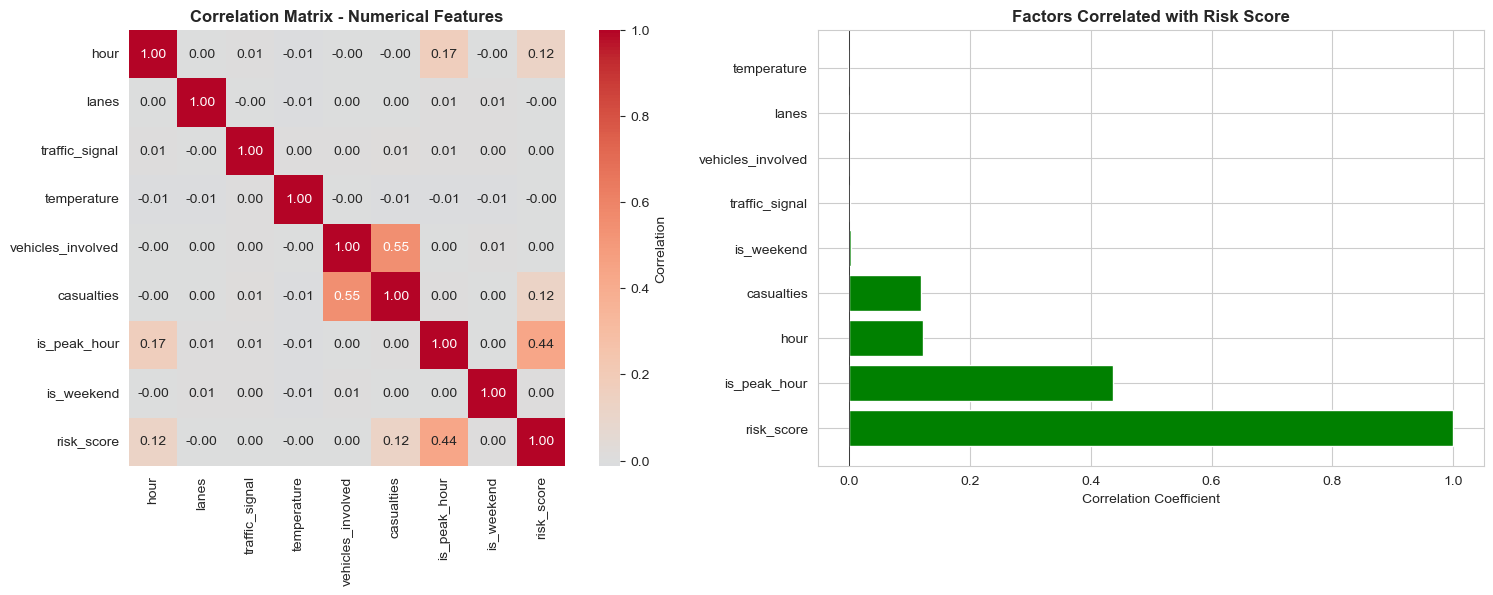


CORRELATION ANALYSIS

Factor Correlations with Risk Score:
risk_score           1.000000
is_peak_hour         0.436848
hour                 0.122017
casualties           0.119954
is_weekend           0.004033
traffic_signal       0.001817
vehicles_involved    0.000642
lanes               -0.001721
temperature         -0.001885
Name: risk_score, dtype: float64


In [52]:
# Create numerical dataframe for correlations
numerical_df = df[['hour', 'lanes', 'traffic_signal', 'temperature', 'vehicles_involved', 
                     'casualties', 'is_peak_hour', 'is_weekend', 'risk_score']].copy()

# Correlation matrix
correlation_matrix = numerical_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix - Numerical Features', fontweight='bold')

# Risk score correlations
risk_correlations = correlation_matrix['risk_score'].sort_values(ascending=False)
axes[1].barh(risk_correlations.index, risk_correlations.values, color=['green' if x > 0 else 'red' for x in risk_correlations.values])
axes[1].set_title('Factors Correlated with Risk Score', fontweight='bold')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("CORRELATION ANALYSIS")
print("="*80)
print("\nFactor Correlations with Risk Score:")
print(risk_correlations)